<a href="https://colab.research.google.com/github/kheira00/-Credit-Scoring-Model-/blob/main/Brain_MRI_UNet_Segmentation_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/archive (2)/data/data"

images	masks


# 🧠 Brain MRI Segmentation using U-Net
### Unit 4 — Medical Image Segmentation

This notebook covers:
1. **U-Net Architecture** (from scratch in PyTorch)
2. **Preprocessing** (Gaussian noise removal, normalization)
3. **Quality Evaluation** (ENL, SSI, EPI, SSIM, PSNR)
4. **Training Loop** with BCE + Dice Loss
5. **Visualization** of predictions

> 📁 **Dataset structure expected:**
> ```
> dataset/
>   images/   ← MRI .png files
>   masks/    ← mask .png files (same filenames as images)
> ```

## 📦 0. Install & Import Dependencies

In [3]:
# Install required libraries (run once)
!pip install torch torchvision matplotlib numpy pillow scikit-image scikit-learn tqdm -q

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from skimage import img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.restoration import denoise_nl_means, estimate_sigma
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')

✅ Using device: cuda


In [5]:
DATA_DIR = "/content/drive/MyDrive/archive (2)/data/data"

In [6]:
IMAGES_DIR = os.path.join(DATA_DIR, 'images')
MASKS_DIR  = os.path.join(DATA_DIR, 'masks')

## ⚙️ 1. Configuration

In [7]:
import os
import torch
import numpy as np

# ============================================================
# Dataset path
# ============================================================
DATA_DIR = "/content/drive/MyDrive/archive (2)/data/data"

IMAGES_DIR = os.path.join(DATA_DIR, 'images')
MASKS_DIR  = os.path.join(DATA_DIR, 'masks')

# Hyperparameters
IMAGE_SIZE  = 256
BATCH_SIZE  = 8
NUM_EPOCHS  = 8
LEARNING_RATE = 1e-4
TRAIN_RATIO = 0.8

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print('✅ Config set.')

# Check files
print(os.listdir(IMAGES_DIR)[:5])
print(os.listdir(MASKS_DIR)[:5])

✅ Config set.
['2895.png', '295.png', '2879.png', '2940.png', '2867.png']
['2847.png', '2860.png', '2868.png', '2836.png', '2933.png']


## 🏗️ 2. U-Net Architecture (from Scratch)

In [8]:
# ---------------------------------------------------------------------------
# Building Block: Double Convolution
# ---------------------------------------------------------------------------
class DoubleConv(nn.Module):
    """Two consecutive Conv2d -> BatchNorm -> ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ---------------------------------------------------------------------------
# Encoder Block (Contracting Path)
# ---------------------------------------------------------------------------
class EncoderBlock(nn.Module):
    """DoubleConv + MaxPool. Returns both the feature map (for skip) and pooled."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)      # saved for skip connection
        down = self.pool(skip)   # passed to next encoder level
        return skip, down


# ---------------------------------------------------------------------------
# Decoder Block (Expansive Path)
# ---------------------------------------------------------------------------
class DecoderBlock(nn.Module):
    """Upsample + concatenate skip connection + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)  # in_channels after concat

    def forward(self, x, skip):
        x = self.up(x)
        # Handle any size mismatch (important for odd input dims)
        if x.shape != skip.shape:
            x = TF.resize(x, size=skip.shape[2:])
        x = torch.cat([skip, x], dim=1)   # concatenate on channel dim
        return self.conv(x)


# ---------------------------------------------------------------------------
# Full U-Net
# ---------------------------------------------------------------------------
class UNet(nn.Module):
    """
    U-Net for binary segmentation.
    Input : (B, in_channels, H, W)
    Output: (B, 1, H, W)  — raw logits (apply sigmoid for probability)
    """
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()

        # Encoder
        self.encoders = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(EncoderBlock(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        self.decoders = nn.ModuleList()
        for f in reversed(features):
            self.decoders.append(DecoderBlock(f * 2, f))

        # Final 1x1 convolution
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []

        # Encoding
        for encoder in self.encoders:
            skip, x = encoder(x)
            skips.append(skip)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoding with skip connections
        for decoder, skip in zip(self.decoders, reversed(skips)):
            x = decoder(x, skip)

        return self.final_conv(x)


# Quick sanity check
model = UNet(in_channels=3, out_channels=1).to(device)
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
out   = model(dummy)
print(f'✅ U-Net output shape: {out.shape}')   # expected (2, 1, 256, 256)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'   Trainable parameters: {total_params:,}')

✅ U-Net output shape: torch.Size([2, 1, 256, 256])
   Trainable parameters: 31,037,633


## 🔬 3. Preprocessing — Gaussian Noise Removal & Normalization
Unlike SAR images (speckle noise), MRI images suffer from **Gaussian noise**.

In [9]:
def add_gaussian_noise(image_np, sigma=0.05):
    """Simulate Gaussian noise on a [0,1] float image"""
    noise = np.random.normal(0, sigma, image_np.shape)
    return np.clip(image_np + noise, 0, 1)


def denoise_gaussian(image_np):
    """
    Denoise an MRI image using Non-Local Means (NLM) — best for Gaussian noise.
    Works on grayscale or RGB float images in [0, 1].
    """
    sigma_est = np.mean(estimate_sigma(image_np, channel_axis=-1 if image_np.ndim == 3 else None))
    denoised  = denoise_nl_means(
        image_np,
        h=1.15 * sigma_est,
        fast_mode=True,
        patch_size=5,
        patch_distance=3,
        channel_axis=-1 if image_np.ndim == 3 else None
    )
    return denoised


def normalize(image_np):
    """Min-max normalization to [0, 1]"""
    mn, mx = image_np.min(), image_np.max()
    if mx - mn < 1e-8:
        return image_np
    return (image_np - mn) / (mx - mn)


def preprocess_mri(image_np):
    """Full preprocessing pipeline for one MRI image"""
    img = img_as_float(image_np)   # convert to float [0, 1]
    img = normalize(img)           # normalize
    img = denoise_gaussian(img)    # denoise
    img = normalize(img)           # re-normalize after denoising
    return img


print('✅ Preprocessing functions defined.')

✅ Preprocessing functions defined.


## 📊 4. Quality Evaluation Metrics
ENL, SSI, EPI, SSIM, PSNR

In [10]:
# ---------------------------------------------------------------------------
# ENL — Equivalent Number of Looks
#   Measures how smooth homogeneous regions are (higher = smoother / less noise)
# ---------------------------------------------------------------------------
def compute_enl(image_np):
    mean = np.mean(image_np)
    std  = np.std(image_np)
    return (mean / (std + 1e-8)) ** 2


# ---------------------------------------------------------------------------
# SSI — Speckle Suppression Index  (adapted for Gaussian noise in MRI)
#   Lower value → more noise suppressed
# ---------------------------------------------------------------------------
def compute_ssi(noisy_np, denoised_np):
    std_noisy    = np.std(noisy_np)
    std_denoised = np.std(denoised_np)
    mean_noisy   = np.mean(noisy_np)
    mean_denoised = np.mean(denoised_np)
    return (std_denoised / (mean_denoised + 1e-8)) / (std_noisy / (mean_noisy + 1e-8))


# ---------------------------------------------------------------------------
# EPI — Edge Preservation Index
#   Measures how well edges are preserved after denoising (closer to 1 = better)
# ---------------------------------------------------------------------------
def compute_epi(original_np, denoised_np):
    from skimage.filters import sobel
    # convert to grayscale if RGB
    if original_np.ndim == 3:
        orig_gray = np.mean(original_np, axis=2)
        deno_gray = np.mean(denoised_np, axis=2)
    else:
        orig_gray = original_np
        deno_gray = denoised_np
    edge_orig = sobel(orig_gray)
    edge_deno = sobel(deno_gray)
    corr = np.corrcoef(edge_orig.ravel(), edge_deno.ravel())[0, 1]
    return corr


# ---------------------------------------------------------------------------
# SSIM & PSNR  (from scikit-image)
# ---------------------------------------------------------------------------
def compute_ssim(original_np, denoised_np):
    ch_axis = -1 if original_np.ndim == 3 else None
    return ssim(original_np, denoised_np, data_range=1.0, channel_axis=ch_axis)


def compute_psnr(original_np, denoised_np):
    return psnr(original_np, denoised_np, data_range=1.0)


# ---------------------------------------------------------------------------
# All metrics in one call
# ---------------------------------------------------------------------------
def evaluate_preprocessing(original_np, noisy_np, denoised_np):
    metrics = {
        'ENL  (noisy)    ': compute_enl(noisy_np),
        'ENL  (denoised) ': compute_enl(denoised_np),
        'SSI             ': compute_ssi(noisy_np, denoised_np),
        'EPI             ': compute_epi(original_np, denoised_np),
        'SSIM            ': compute_ssim(original_np, denoised_np),
        'PSNR (dB)       ': compute_psnr(original_np, denoised_np),
    }
    return metrics


print('✅ Metric functions defined.')

✅ Metric functions defined.


## 📂 5. Dataset Class

In [11]:
class BrainMRIDataset(Dataset):
    """
    Dataset for Brain MRI Segmentation.
    Expects two folders with matching filenames:
      images/  <- MRI .png files
      masks/   <- mask .png files (same filename as image)
    """
    def __init__(self, image_paths, mask_paths, img_size=256, augment=False, apply_preproc=True):
        self.image_paths   = image_paths
        self.mask_paths    = mask_paths
        self.img_size      = img_size
        self.augment       = augment
        self.apply_preproc = apply_preproc

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image (RGB) and mask (grayscale)
        image = np.array(Image.open(self.image_paths[idx]).convert('RGB').resize(
            (self.img_size, self.img_size), Image.BILINEAR))
        mask  = np.array(Image.open(self.mask_paths[idx]).convert('L').resize(
            (self.img_size, self.img_size), Image.NEAREST))

        # Preprocess image
        if self.apply_preproc:
            image = preprocess_mri(image)
        else:
            image = img_as_float(image)

        # Binarize mask (0 or 1)
        mask = (mask > 127).astype(np.float32)

        # Convert to tensors
        image = torch.from_numpy(image.transpose(2, 0, 1)).float()  # (3, H, W)
        mask  = torch.from_numpy(mask).unsqueeze(0).float()          # (1, H, W)

        # Augmentation (training only)
        if self.augment and torch.rand(1) > 0.5:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)
        if self.augment and torch.rand(1) > 0.5:
            image = TF.vflip(image)
            mask  = TF.vflip(mask)

        return image, mask


# ---------------------------------------------------------------------------
# Collect matching image/mask pairs from images/ and masks/ folders
# ---------------------------------------------------------------------------
def get_image_mask_paths(images_dir, masks_dir):
    image_paths = sorted(glob.glob(os.path.join(images_dir, '*.png')))
    pairs = []
    for img_path in image_paths:
        filename  = os.path.basename(img_path)
        mask_path = os.path.join(masks_dir, filename)
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))
        else:
            print(f'⚠️  No mask found for: {filename} — skipping')
    print(f'✅ Found {len(pairs)} valid image-mask pairs.')
    return zip(*pairs) if pairs else ([], [])


all_images, all_masks = get_image_mask_paths(IMAGES_DIR, MASKS_DIR)
all_images, all_masks = list(all_images), list(all_masks)

# Train / Val split
tr_imgs, val_imgs, tr_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=1-TRAIN_RATIO, random_state=42)

train_ds = BrainMRIDataset(tr_imgs,  tr_masks,  img_size=IMAGE_SIZE, augment=True)
val_ds   = BrainMRIDataset(val_imgs, val_masks, img_size=IMAGE_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'   Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')

⚠️  No mask found for: 1445 (1).png — skipping
⚠️  No mask found for: 1446 (1).png — skipping
⚠️  No mask found for: 1448 (1).png — skipping
⚠️  No mask found for: 1449 (1).png — skipping
⚠️  No mask found for: 145 (1).png — skipping
⚠️  No mask found for: 1450 (1).png — skipping
⚠️  No mask found for: 1451 (1).png — skipping
⚠️  No mask found for: 1452 (1).png — skipping
⚠️  No mask found for: 1453 (1).png — skipping
⚠️  No mask found for: 1454 (1).png — skipping
⚠️  No mask found for: 1455 (1).png — skipping
⚠️  No mask found for: 1456 (1).png — skipping
⚠️  No mask found for: 1457 (1).png — skipping
⚠️  No mask found for: 1458 (1).png — skipping
⚠️  No mask found for: 1459 (1).png — skipping
⚠️  No mask found for: 192 (1).png — skipping
⚠️  No mask found for: 192 (2).png — skipping
⚠️  No mask found for: 1921 (1).png — skipping
⚠️  No mask found for: 1922 (1).png — skipping
⚠️  No mask found for: 1924 (1).png — skipping
⚠️  No mask found for: 1925 (1).png — skipping
⚠️  No mask foun

## 🖼️ 6. Visualize Preprocessing Quality + Metrics

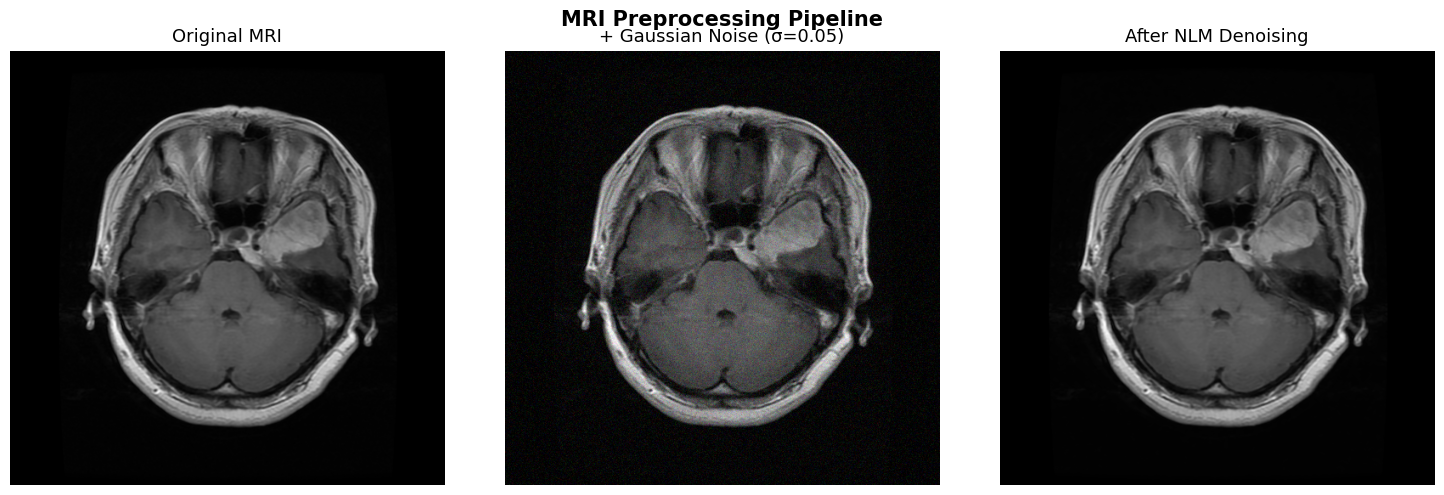


📊 Preprocessing Quality Metrics
  ENL  (noisy)    : 0.6107
  ENL  (denoised) : 0.5113
  SSI             : 1.0929
  EPI             : 0.9998
  SSIM            : 0.9989
  PSNR (dB)       : 60.1174


In [12]:
# Pick one sample image for demonstration
sample_path = all_images[0]  # first image from images/ folder
original_np = img_as_float(np.array(Image.open(sample_path).convert('RGB')))
original_np = normalize(original_np)

# Simulate Gaussian noise (as in real MRI acquisition)
noisy_np    = add_gaussian_noise(original_np, sigma=0.05)
denoised_np = preprocess_mri(np.array(Image.open(sample_path).convert('RGB')))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_np); axes[0].set_title('Original MRI', fontsize=13); axes[0].axis('off')
axes[1].imshow(noisy_np);    axes[1].set_title('+ Gaussian Noise (σ=0.05)', fontsize=13); axes[1].axis('off')
axes[2].imshow(denoised_np); axes[2].set_title('After NLM Denoising', fontsize=13); axes[2].axis('off')
plt.suptitle('MRI Preprocessing Pipeline', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_demo.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print metrics ---
metrics = evaluate_preprocessing(original_np, noisy_np, denoised_np)
print('\n📊 Preprocessing Quality Metrics')
print('=' * 42)
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}')

## ⚖️ 7. Loss Functions

In [13]:
class DiceLoss(nn.Module):
    """Dice Loss for binary segmentation"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        dice = (2.0 * intersection + self.smooth) / \
               (probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + self.smooth)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    """Combined BCE + Dice Loss (best for medical image segmentation)"""
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        bce_loss  = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


print('✅ Loss functions defined.')

✅ Loss functions defined.


## 📈 8. Evaluation Metrics (Segmentation)

In [14]:
def dice_score(pred_logits, targets, threshold=0.5):
    """Dice coefficient for evaluating segmentation quality"""
    pred  = (torch.sigmoid(pred_logits) > threshold).float()
    inter = (pred * targets).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice  = (2.0 * inter + 1e-6) / (union + 1e-6)
    return dice.mean().item()


def iou_score(pred_logits, targets, threshold=0.5):
    """Intersection over Union"""
    pred  = (torch.sigmoid(pred_logits) > threshold).float()
    inter = (pred * targets).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - inter
    iou   = (inter + 1e-6) / (union + 1e-6)
    return iou.mean().item()


print('✅ Segmentation evaluation metrics defined.')

✅ Segmentation evaluation metrics defined.


## 🏋️ 9. Training Loop

In [15]:
# Initialize model, loss, optimizer
model     = UNet(in_channels=3, out_channels=1).to(device)
criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# History tracking
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

best_val_loss = float('inf')
best_epoch    = 0


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc='  Training', leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    for images, masks in tqdm(loader, desc='  Validation', leave=False):
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss   = criterion(logits, masks)
        total_loss += loss.item()
        total_dice += dice_score(logits, masks)
        total_iou  += iou_score(logits, masks)
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


# ---- Main Training Loop ----
print(f'🚀 Starting training for {NUM_EPOCHS} epochs...')
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss              = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_dice, val_iou = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), 'best_unet_mri.pth')

    print(f'Epoch [{epoch:>3}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Dice: {val_dice:.4f} | '
          f'IoU: {val_iou:.4f}')

print(f'\n✅ Training complete. Best model saved at epoch {best_epoch} (val_loss={best_val_loss:.4f})')

🚀 Starting training for 8 epochs...


Epoch [  1/8]  Train Loss: 0.6243 | Val Loss: 0.5639 | Dice: 0.4166 | IoU: 0.3043


Epoch [  2/8]  Train Loss: 0.5284 | Val Loss: 0.5087 | Dice: 0.4001 | IoU: 0.2761


Epoch [  3/8]  Train Loss: 0.4544 | Val Loss: 0.4054 | Dice: 0.5984 | IoU: 0.4861


Epoch [  4/8]  Train Loss: 0.3808 | Val Loss: 0.3417 | Dice: 0.5941 | IoU: 0.4885


Epoch [  5/8]  Train Loss: 0.3119 | Val Loss: 0.3032 | Dice: 0.5887 | IoU: 0.4917


Epoch [  6/8]  Train Loss: 0.2527 | Val Loss: 0.2336 | Dice: 0.6848 | IoU: 0.5875


Epoch [  7/8]  Train Loss: 0.2219 | Val Loss: 0.1991 | Dice: 0.7019 | IoU: 0.6073


Epoch [  8/8]  Train Loss: 0.2011 | Val Loss: 0.1800 | Dice: 0.7225 | IoU: 0.6246

✅ Training complete. Best model saved at epoch 8 (val_loss=0.1800)


## 📉 10. Training Curves

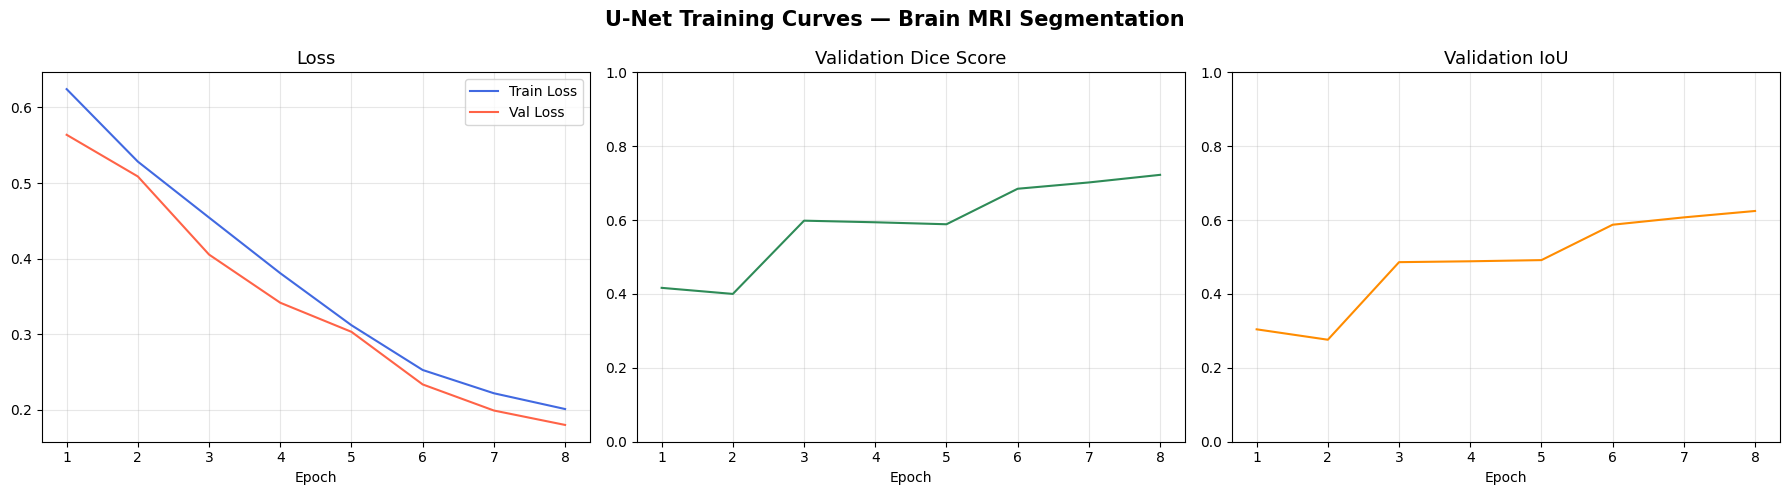

In [16]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss', fontsize=13); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Dice
axes[1].plot(epochs, history['val_dice'], color='seagreen')
axes[1].set_title('Validation Dice Score', fontsize=13); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)

# IoU
axes[2].plot(epochs, history['val_iou'], color='darkorange')
axes[2].set_title('Validation IoU', fontsize=13); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1); axes[2].grid(True, alpha=0.3)

plt.suptitle('U-Net Training Curves — Brain MRI Segmentation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 11. Qualitative Results — Prediction Visualization

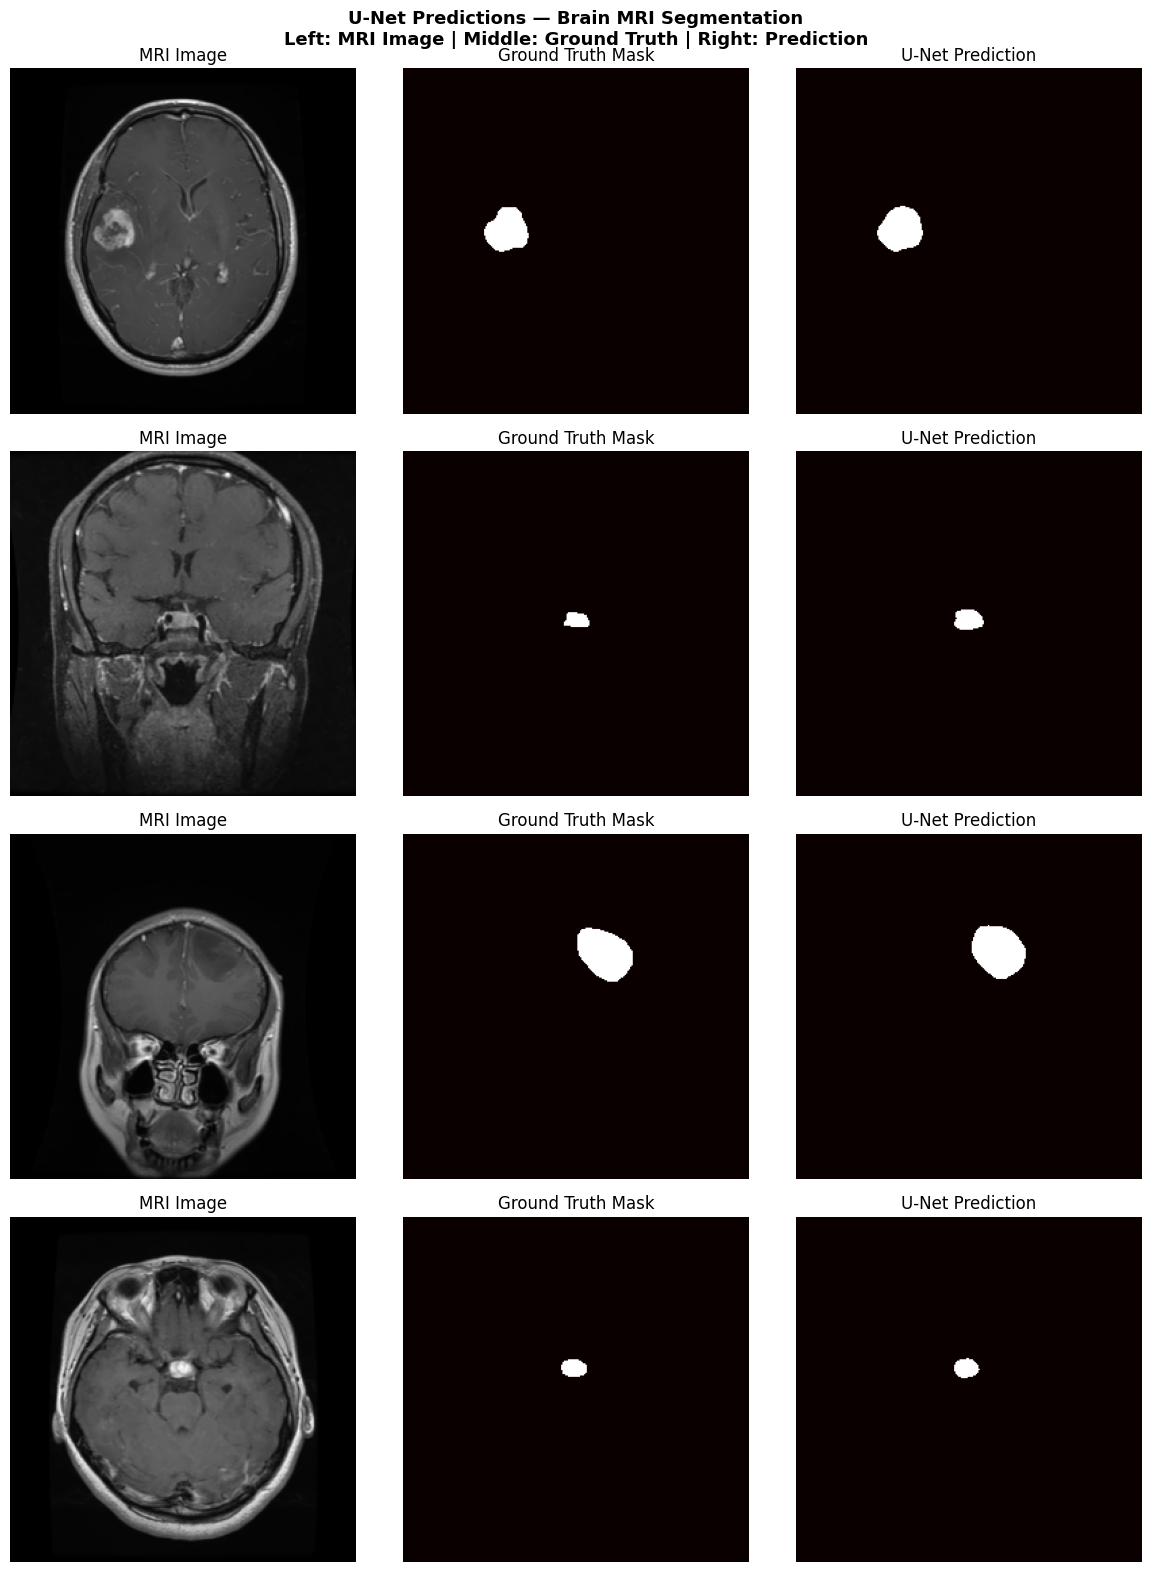

In [17]:
# Load best model
model.load_state_dict(torch.load('best_unet_mri.pth', map_location=device))
model.eval()


def visualize_predictions(model, dataset, num_samples=4):
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    fig.suptitle('U-Net Predictions — Brain MRI Segmentation\n'
                 'Left: MRI Image | Middle: Ground Truth | Right: Prediction',
                 fontsize=13, fontweight='bold')

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        with torch.no_grad():
            logit = model(image.unsqueeze(0).to(device))
            pred  = (torch.sigmoid(logit) > 0.5).squeeze().cpu().numpy()

        img_np  = image.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title('MRI Image'); axes[row, 0].axis('off')

        axes[row, 1].imshow(mask_np, cmap='hot')
        axes[row, 1].set_title('Ground Truth Mask'); axes[row, 1].axis('off')

        axes[row, 2].imshow(pred, cmap='hot')
        axes[row, 2].set_title('U-Net Prediction'); axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(model, val_ds, num_samples=4)

## 🔬 12. Overlay: Prediction on MRI Image

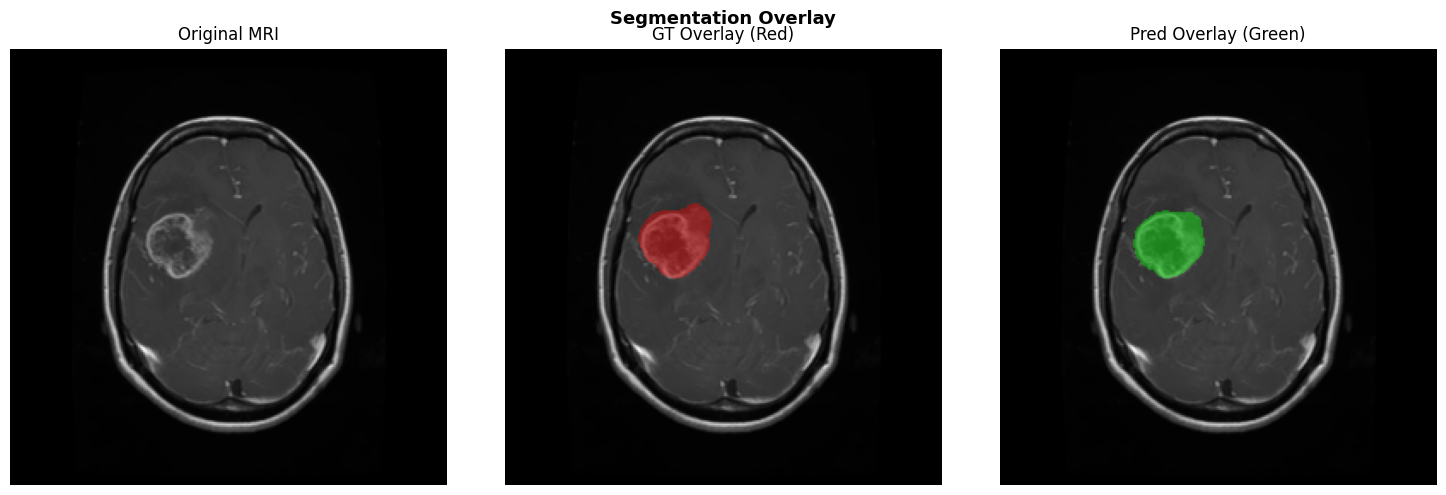

In [18]:
def overlay_prediction(model, dataset, idx=0, alpha=0.4):
    image, mask = dataset[idx]
    with torch.no_grad():
        logit = model(image.unsqueeze(0).to(device))
        pred  = (torch.sigmoid(logit) > 0.5).squeeze().cpu().numpy()

    img_np  = image.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze().numpy()

    # Create overlay
    overlay_gt   = img_np.copy()
    overlay_pred = img_np.copy()
    overlay_gt[mask_np > 0.5]  = overlay_gt[mask_np > 0.5]  * (1 - alpha) + np.array([1, 0, 0]) * alpha
    overlay_pred[pred > 0.5]   = overlay_pred[pred > 0.5]   * (1 - alpha) + np.array([0, 1, 0]) * alpha

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np);       axes[0].set_title('Original MRI');         axes[0].axis('off')
    axes[1].imshow(overlay_gt);   axes[1].set_title('GT Overlay (Red)');      axes[1].axis('off')
    axes[2].imshow(overlay_pred); axes[2].set_title('Pred Overlay (Green)');  axes[2].axis('off')
    plt.suptitle('Segmentation Overlay', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('overlay.png', dpi=150, bbox_inches='tight')
    plt.show()


overlay_prediction(model, val_ds, idx=0)

## 📋 13. Final Summary Report

In [19]:
@torch.no_grad()
def final_report(model, loader, criterion):
    val_loss, val_dice, val_iou = validate(model, loader, criterion)
    print('=' * 50)
    print('   📊 FINAL EVALUATION REPORT')
    print('=' * 50)
    print(f'   Best Epoch       : {best_epoch}')
    print(f'   Val Loss         : {val_loss:.4f}')
    print(f'   Dice Score       : {val_dice:.4f}')
    print(f'   IoU Score        : {val_iou:.4f}')
    print('=' * 50)


final_report(model, val_loader, criterion)

   📊 FINAL EVALUATION REPORT
   Best Epoch       : 8
   Val Loss         : 0.1800
   Dice Score       : 0.7225
   IoU Score        : 0.6246


---
## ✅ Summary

| Component | Details |
|---|---|
| **Architecture** | U-Net with skip connections (4 encoder + bottleneck + 4 decoder blocks) |
| **Noise type** | Gaussian (unlike SAR which has speckle) |
| **Denoising** | Non-Local Means (NLM) — optimal for Gaussian noise |
| **Normalization** | Min-Max per image |
| **Metrics** | ENL, SSI, EPI, SSIM, PSNR (preprocessing) + Dice, IoU (segmentation) |
| **Loss** | BCE + Dice (50/50 weighted) |
| **Optimizer** | Adam with ReduceLROnPlateau |
| **Augmentation** | Horizontal + Vertical flips |